# Lecture practicals

## Week 1
Selected time series dataset
https://opendata.swiss/de/dataset/kantonaler-stromverbrauch-netzlast

Reflect on the data generation process:
- How was the data collected? Time interval, time range, etc.

How: From electricty usage meters and how much electricty was put into the grid
Interval: 15 minutes
Range: 30.12.2011 - 15.09.2025

- Which factors/laws influence the data?

Transmission loss
Subsidization of local solar panels, which are not measured

- Which patterns do you expect to find?

Yearly seasons
day/night cycles

Review notebooks of Modern Time Series Forecasting with Python – Chapter 2 (GitHub repository)
https://github.com/PacktPublishing/Modern-Time-Series-Forecasting-with-Python/tree/main/notebooks/Chapter02

Load and visualize datasets with Python.
Analysis:
- Explain and interpret the plots. How noisy is the data?

Due to the small interval and large range the visualization is very noisy.
Therefore seaonal and daily cycles are not really visibly.
The predicted trend towards less energy consumption due to solar power over the years is visible. 

- Review patterns, do they match your expectations given your understanding of the DGP?

The general nosiyness was expected due to the large number of data points.

Large range of values as well, due to the small interval measuring the change of demand which changes by the minute.

- Review outliers, interpret them, and match with corresponding real-world events when applicable

There is a big dip in may 2020, which corresponds with the COVID19 pandemic. Due to everyone having to isolate a lot less energy was needed.

In [ ]:
import pandas as pd
df = pd.read_parquet("basel-energy-demand.parquet")
df.head()

In [ ]:
df.dtypes

In [ ]:
import plotly.express as px

fig = px.line(df, x='timestamp_interval_start', y="stromverbrauch_kwh", title='Basel Energy Demand')
fig.show()

In [13]:
# Ensure yfinance is available for fallback downloads if needed
try:
    import yfinance as yf
    print('yfinance is available')
except Exception:
    import sys, subprocess
    print('Installing yfinance...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'yfinance'])
    import yfinance as yf
    print('yfinance installed')

IndentationError: expected an indented block after 'try' statement on line 2 (910651655.py, line 3)

In [17]:
# Load weekly oil prices dataset (local if available, otherwise fallback to yfinance CL=F)
import os
import pandas as pd
import numpy as np
local_path = '../data/oil.csv'
if os.path.exists(local_path):
    raw = pd.read_csv(local_path, parse_dates=['date'])
else:
    print('Local oil.csv not found; attempting to download from yfinance (CL=F)')
    import yfinance as yf
    df_yf = yf.download('CL=F', period='10y', interval='1d')
    df_yf = df_yf[['Close']].rename(columns={'Close': 'dcoilwtico'})
    df_yf = df_yf.reset_index()  # 'Date' column is created
    # flatten columns if there is a MultiIndex
    if isinstance(df_yf.columns, pd.MultiIndex):
        df_yf.columns = df_yf.columns.get_level_values(0)
    if 'Date' in df_yf.columns:
        df_yf.rename(columns={'Date': 'date'}, inplace=True)
    df_yf['date'] = pd.to_datetime(df_yf['date'])
    raw = df_yf.set_index('date')
# data preprocessing similar to rish.get_oil_weekly_prices()
raw['dcoilwtico'] = raw['dcoilwtico'].ffill(limit=2)
weekly = raw.resample('W-FRI').last()
weekly['closing'] = weekly['dcoilwtico']
oil_data = weekly[['closing']]
oil_data.head()

/tmp/ipykernel_804038/880089280.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_yf = yf.download('CL=F', period='10y', interval='1d')
[*********************100%***********************]  1 of 1 completed

Local oil.csv not found; attempting to download from yfinance (CL=F)


Price,closing
date,
2015-12-18,34.730000
2015-12-25,38.099998
2016-01-01,37.040001
2016-01-08,33.160000
2016-01-15,29.420000


In [18]:
# Debug: inspect raw and weekly DataFrames if yfinance fallback used
try:
    print('df_yf shape:', df_yf.shape)
    print('df_yf index min/max:', df_yf['date'].min(), df_yf['date'].max())
    print('df_yf columns:', df_yf.columns)
    display(df_yf.head())
except NameError:
    print('df_yf not defined')

print('Weekly head and shape:')
print(weekly.shape)
print(weekly.index.min(), weekly.index.max())
print(weekly.head())

print('oil_data summary:')
print(oil_data.shape)
print(oil_data.head())

df_yf shape: (2515, 2)
df_yf index min/max: 2015-12-14 00:00:00 2025-12-12 00:00:00
df_yf columns: Index(['date', 'dcoilwtico'], dtype='object', name='Price')


Price,date,dcoilwtico
0,2015-12-14,36.310001
1,2015-12-15,37.349998
2,2015-12-16,35.520000
3,2015-12-17,34.950001
4,2015-12-18,34.730000


Weekly head and shape:
(522, 2)
2015-12-18 00:00:00 2025-12-12 00:00:00
Price       dcoilwtico    closing
date                             
2015-12-18   34.730000  34.730000
2015-12-25   38.099998  38.099998
2016-01-01   37.040001  37.040001
2016-01-08   33.160000  33.160000
2016-01-15   29.420000  29.420000
oil_data summary:
(522, 1)
Price         closing
date                 
2015-12-18  34.730000
2015-12-25  38.099998
2016-01-01  37.040001
2016-01-08  33.160000
2016-01-15  29.420000


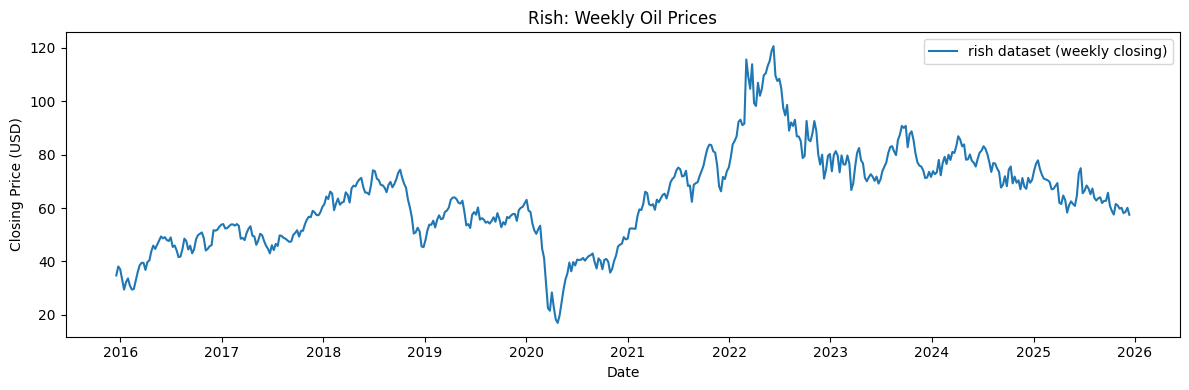

In [19]:
# Plot the 'rish' dataset (oil weekly closing prices)
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(oil_data.index, oil_data['closing'], label='rish dataset (weekly closing)')
ax.set_title('Rish: Weekly Oil Prices')
ax.set_xlabel('Date')
ax.set_ylabel('Closing Price (USD)')
ax.legend()
plt.tight_layout()

Dataset metadata: Weekly Oil Prices (from rish data / fallback)
Source: yfinance CL=F
Number of observations: 522
Time Range: 2015-12-18 00:00:00 to 2025-12-12 00:00:00
Mean interval: 7 days 00:00:00; Mode interval: 7 days 00:00:00; Std interval: 0 days 00:00:00
Trend
Estimated linear trend slope: 0.067312 USD/week (approx 3.50 USD/year)
Stationarity of remainder
ADF p-value: 1.9923224604219105e-08
KPSS p-value: 0.1